### Dataset: Energy Efficiency with CL (cooling load) as target

In [1]:
from ucimlrepo import fetch_ucirepo

energy_efficiency = fetch_ucirepo(id=242) 
  
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets

var_df = energy_efficiency.variables
col_map = dict(zip(var_df["name"], var_df["description"]))
X = X.rename(columns=col_map)
y = y.rename(columns=col_map)

y = y[["Cooling Load"]]
df = X.join(y)
df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,28.28


### Train test split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,     
    random_state=42,   
    shuffle=True
)

print(f"#X_train = {len(X_train)}   #y_train = {len(y_train)}")
print(f"#X_test = {len(X_test)}     #y_test = {len(y_test)}")

#X_train = 691   #y_train = 691
#X_test = 77     #y_test = 77


### EDF normalization

In [3]:
from src.edf import edf_normalize, col_denorm

X_train_norm, X_test_norm, _ = edf_normalize(X_train, X_test)
y_train_norm, y_test_norm, edf_models = edf_normalize(y_train, y_test)

y_denorm = col_denorm("Cooling Load", edf_models)

 ### Relevance (feature deg. 4, target deg. 4)

In [ ]:
from src.evaluation import relevance, report_relevance

columns_relevance = {}
for col in X.columns:
    print(f"--- Evaluating relevance for feature: {col} ---")

    softplus_relevance = relevance(X_train_norm, X_test_norm,
                                   y_train_norm, y_test_norm,
                                   col, y_test, y_denorm,   
                                   N_feature=4, N_target=4)
    
    param_softplus_relevance = relevance(X_train_norm, X_test_norm,
                                         y_train_norm, y_test_norm,
                                         col, y_test, y_denorm,
                                         N_feature=4, N_target=4,
                                         method="softplus", a=3., b=100.)

    clip_relevance = relevance(X_train_norm, X_test_norm,
                               y_train_norm, y_test_norm,
                               col, y_test, y_denorm,  
                               N_feature=4, N_target=4,
                               method="clip")
    
    columns_relevance[col] = {
        "softplus": softplus_relevance,
        "param-softplus": param_softplus_relevance,
        "clip": clip_relevance
    }

In [5]:
report_relevance(columns_relevance, method="softplus")

Feature Relevance Ranking (method: softplus):
1. Roof Area: 0.4270
2. Relative Compactness: 0.4069
3. Surface Area: 0.4015
4. Overall Height: 0.3697
5. Wall Area: 0.2479
6. Glazing Area: 0.1486
7. Glazing Area Distribution: 0.0777
8. Orientation: -0.0063


In [6]:
report_relevance(columns_relevance, method="param-softplus")

Feature Relevance Ranking (method: param-softplus):
1. Relative Compactness: 0.7233
2. Surface Area: 0.6730
3. Roof Area: 0.6687
4. Overall Height: 0.5682
5. Wall Area: 0.1432
6. Glazing Area Distribution: 0.0252
7. Orientation: -0.0435
8. Glazing Area: -0.0498


In [7]:
report_relevance(columns_relevance, method="clip")

Feature Relevance Ranking (method: clip):
1. Roof Area: 0.6392
2. Relative Compactness: 0.6056
3. Surface Area: 0.6010
4. Overall Height: 0.5857
5. Wall Area: 0.2867
6. Glazing Area: 0.1264
7. Glazing Area Distribution: 0.0835
8. Orientation: -0.0121


In [8]:
import pandas as pd

df_relevance = pd.DataFrame.from_dict(
    columns_relevance,
    orient="index"
)
df_relevance

,softplus,param-softplus,clip
Relative Compactness,0.406867,0.723265,0.605576
Surface Area,0.401506,0.673011,0.600987
Wall Area,0.247925,0.143203,0.286664
Roof Area,0.427034,0.668699,0.639153
Overall Height,0.369678,0.568241,0.585706
Orientation,-0.006323,-0.043462,-0.012093
Glazing Area,0.148596,-0.049823,0.126416
Glazing Area Distribution,0.077722,0.025232,0.083500


 ### CV for relevance (feature deg. 4, target deg. 4)

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
softplus_results = cv_relevance(X, y,
                                N_feature=4, N_target=4)

CV Relevance Results (method: softplus):

Feature: Relative Compactness
  per fold: [0.37 0.38 0.37 0.4  0.37 0.37 0.35 0.39 0.38 0.39]
  mean relevance : 0.3786
  std relevance  : 0.0141

Feature: Surface Area
  per fold: [0.36 0.4  0.37 0.4  0.37 0.37 0.35 0.4  0.37 0.39]
  mean relevance : 0.3787
  std relevance  : 0.0160

Feature: Wall Area
  per fold: [0.17 0.21 0.19 0.25 0.29 0.16 0.19 0.24 0.29 0.19]
  mean relevance : 0.2184
  std relevance  : 0.0454

Feature: Roof Area
  per fold: [0.4  0.4  0.39 0.42 0.46 0.39 0.37 0.45 0.41 0.37]
  mean relevance : 0.4061
  std relevance  : 0.0273

Feature: Overall Height
  per fold: [0.36 0.35 0.35 0.36 0.38 0.34 0.32 0.37 0.36 0.33]
  mean relevance : 0.3528
  std relevance  : 0.0186

Feature: Orientation
  per fold: [-0.   -0.01 -0.   -0.01 -0.01 -0.01 -0.   -0.   -0.   -0.01]
  mean relevance : -0.0061
  std relevance  : 0.0040

Feature: Glazing Area
  per fold: [0.15 0.13 0.12 0.11 0.19 0.18 0.14 0.11 0.13 0.08]
  mean relevance : 0.134

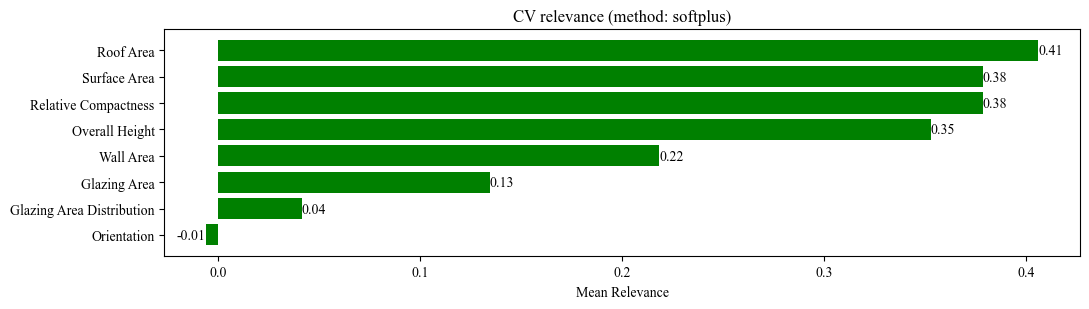

In [10]:
print_cv_relevance(softplus_results, X.columns)
plot_cv_relevance(softplus_results, X.columns)

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
param_softplus_results = cv_relevance(X, y,
                                      N_feature=4, N_target=4,
                                      method="softplus", a=3., b=100.)

CV Relevance Results (method: param-softplus):

Feature: Relative Compactness
  per fold: [0.57 0.62 0.56 0.71 0.52 0.61 0.48 0.61 0.62 0.62]
  mean relevance : 0.5915
  std relevance  : 0.0600

Feature: Surface Area
  per fold: [0.5  0.61 0.53 0.68 0.48 0.58 0.45 0.61 0.55 0.6 ]
  mean relevance : 0.5580
  std relevance  : 0.0665

Feature: Wall Area
  per fold: [-0.26  0.01 -0.06  0.14  0.31 -0.23 -0.08  0.15  0.32 -0.03]
  mean relevance : 0.0273
  std relevance  : 0.1899

Feature: Roof Area
  per fold: [0.54 0.68 0.55 0.66 0.74 0.58 0.43 0.74 0.62 0.48]
  mean relevance : 0.6016
  std relevance  : 0.0979

Feature: Overall Height
  per fold: [0.51 0.52 0.51 0.53 0.63 0.44 0.35 0.59 0.53 0.4 ]
  mean relevance : 0.4993
  std relevance  : 0.0787

Feature: Orientation
  per fold: [-0.01 -0.05 -0.02 -0.05 -0.08 -0.08 -0.03 -0.02 -0.02 -0.05]
  mean relevance : -0.0399
  std relevance  : 0.0235

Feature: Glazing Area
  per fold: [ 0.07 -0.01  0.05 -0.2   0.18  0.05  0.   -0.08 -0.1  -0.15

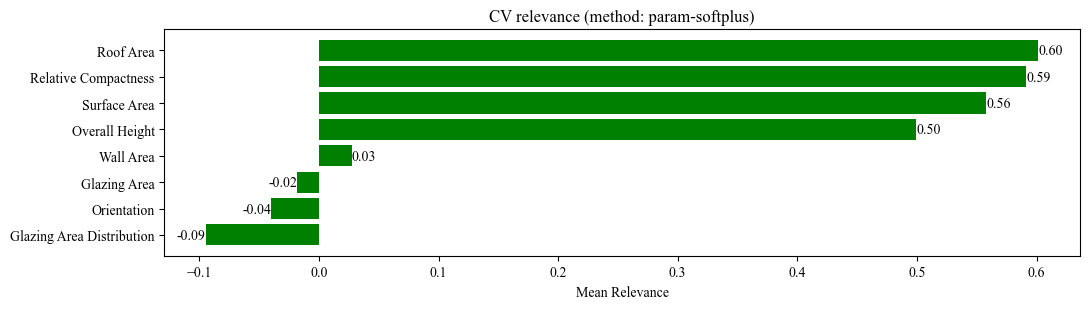

In [12]:
print_cv_relevance(param_softplus_results, X.columns, method="param-softplus")
plot_cv_relevance(param_softplus_results, X.columns, method="param-softplus")

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
clip_results = cv_relevance(X, y,
                            N_feature=4, N_target=4,
                            method="clip")

CV Relevance Results (method: clip):

Feature: Relative Compactness
  per fold: [0.55 0.57 0.55 0.6  0.54 0.56 0.52 0.56 0.56 0.58]
  mean relevance : 0.5592
  std relevance  : 0.0202

Feature: Surface Area
  per fold: [0.54 0.58 0.56 0.6  0.55 0.56 0.51 0.58 0.54 0.58]
  mean relevance : 0.5599
  std relevance  : 0.0252

Feature: Wall Area
  per fold: [-0.    0.15  0.19  0.29  0.3   0.02 -0.09  0.35  0.43  0.18]
  mean relevance : 0.1833
  std relevance  : 0.1575

Feature: Roof Area
  per fold: [0.59 0.61 0.6  0.63 0.68 0.6  0.55 0.66 0.63 0.58]
  mean relevance : 0.6134
  std relevance  : 0.0371

Feature: Overall Height
  per fold: [0.57 0.57 0.57 0.57 0.61 0.55 0.51 0.59 0.57 0.53]
  mean relevance : 0.5647
  std relevance  : 0.0257

Feature: Orientation
  per fold: [-0.   -0.01 -0.01 -0.02 -0.03 -0.02 -0.01 -0.01 -0.   -0.01]
  mean relevance : -0.0117
  std relevance  : 0.0075

Feature: Glazing Area
  per fold: [ 0.22  0.    0.02 -0.06  0.27  0.07  0.2  -0.02 -0.    0.1 ]
  mean r

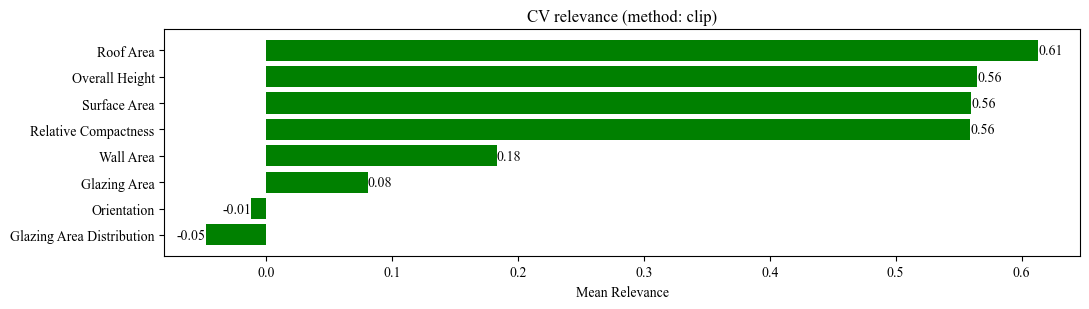

In [14]:
print_cv_relevance(clip_results, X.columns, method="clip")
plot_cv_relevance(clip_results, X.columns, method="clip")

In [15]:
from src.evaluation import relevance_to_df
relevance_df = relevance_to_df(softplus_results,
                               param_softplus_results,
                               clip_results)
relevance_df

softplus           param_softplus            \
                               mean       std           mean       std   
feature                                                                  
Relative Compactness       0.378604  0.014080       0.591465  0.060035   
Surface Area               0.378696  0.016036       0.558018  0.066483   
Wall Area                  0.218357  0.045415       0.027264  0.189875   
Roof Area                  0.406133  0.027289       0.601554  0.097877   
Overall Height             0.352795  0.018610       0.499345  0.078687   
Orientation               -0.006080  0.003968      -0.039949  0.023483   
Glazing Area               0.134495  0.032907      -0.017964  0.108617   
Glazing Area Distribution  0.041481  0.025016      -0.094569  0.074123   

                               clip            
                               mean       std  
feature                                        
Relative Compactness       0.559159  0.020173  
Surface Area               0.559908  0.025173  
Wall Area                  0.183322  0.157471  
Roof Area                  0.613356  0.037119  
Overall Height             0.564673  0.025745  
Orientation               -0.011696  0.007535  
Glazing Area               0.080879  0.107828  
Glazing Area Distribution -0.047898  0.139820

 ### Relevance (feature deg. 7, target deg. 8)

In [ ]:
from src.evaluation import relevance, report_relevance

columns_relevance_higher_degs = {}
for col in X.columns:
    print(f"--- Evaluating relevance for feature: {col} ---")

    softplus_relevance = relevance(X_train_norm, X_test_norm,
                                   y_train_norm, y_test_norm,
                                   col, y_test, y_denorm,   
                                   N_feature=7, N_target=8)
    
    param_softplus_relevance = relevance(X_train_norm, X_test_norm,
                                         y_train_norm, y_test_norm,
                                         col, y_test, y_denorm,
                                         N_feature=7, N_target=8,
                                         method="softplus", a=3., b=100.)

    clip_relevance = relevance(X_train_norm, X_test_norm,
                               y_train_norm, y_test_norm,
                               col, y_test, y_denorm,  
                               N_feature=7, N_target=8,
                               method="clip")
    
    columns_relevance_higher_degs[col] = {
        "softplus": softplus_relevance,
        "param-softplus": param_softplus_relevance,
        "clip": clip_relevance
    }

In [17]:
report_relevance(columns_relevance_higher_degs, method="softplus")

Feature Relevance Ranking (method: softplus):
1. Surface Area: 0.5825
2. Relative Compactness: 0.5699
3. Roof Area: 0.4587
4. Wall Area: 0.3910
5. Overall Height: 0.3759
6. Glazing Area: 0.2432
7. Glazing Area Distribution: 0.0923
8. Orientation: -0.0194


In [18]:
report_relevance(columns_relevance_higher_degs, method="param-softplus")

Feature Relevance Ranking (method: param-softplus):
1. Surface Area: 0.7772
2. Relative Compactness: 0.7314
3. Roof Area: 0.5996
4. Overall Height: 0.5699
5. Wall Area: 0.3432
6. Glazing Area Distribution: -0.0341
7. Glazing Area: -0.1228
8. Orientation: -0.1264


In [19]:
report_relevance(columns_relevance_higher_degs, method="clip")

Feature Relevance Ranking (method: clip):
1. Surface Area: 0.8140
2. Relative Compactness: 0.7686
3. Roof Area: 0.7018
4. Overall Height: 0.6124
5. Wall Area: 0.5481
6. Glazing Area: 0.1318
7. Glazing Area Distribution: 0.0918
8. Orientation: -0.0378


In [20]:
import pandas as pd

df_relevance = pd.DataFrame.from_dict(
    columns_relevance_higher_degs,
    orient="index"
)
df_relevance

,softplus,param-softplus,clip
Relative Compactness,0.569932,0.731400,0.768573
Surface Area,0.582531,0.777216,0.813975
Wall Area,0.390984,0.343177,0.548128
Roof Area,0.458662,0.599558,0.701779
Overall Height,0.375896,0.569886,0.612394
Orientation,-0.019357,-0.126354,-0.037805
Glazing Area,0.243167,-0.122824,0.131772
Glazing Area Distribution,0.092273,-0.034074,0.091843


 ### CV for relevance (feature deg. 7, target deg. 8)

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
softplus_results_higher_degs = cv_relevance(X, y,
                                            N_feature=7, N_target=8)

CV Relevance Results (method: softplus):

Feature: Relative Compactness
  per fold: [0.54 0.57 0.55 0.58 0.59 0.56 0.55 0.56 0.54 0.6 ]
  mean relevance : 0.5637
  std relevance  : 0.0181

Feature: Surface Area
  per fold: [0.57 0.57 0.53 0.57 0.55 0.53 0.52 0.58 0.53 0.58]
  mean relevance : 0.5537
  std relevance  : 0.0227

Feature: Wall Area
  per fold: [0.4  0.41 0.31 0.42 0.42 0.3  0.3  0.35 0.35 0.34]
  mean relevance : 0.3611
  std relevance  : 0.0471

Feature: Roof Area
  per fold: [0.39 0.48 0.44 0.46 0.52 0.43 0.41 0.5  0.45 0.42]
  mean relevance : 0.4500
  std relevance  : 0.0378

Feature: Overall Height
  per fold: [0.35 0.4  0.38 0.39 0.41 0.37 0.35 0.39 0.39 0.36]
  mean relevance : 0.3783
  std relevance  : 0.0187

Feature: Orientation
  per fold: [-0.01 -0.01 -0.02 -0.02 -0.02 -0.02 -0.01 -0.   -0.   -0.01]
  mean relevance : -0.0137
  std relevance  : 0.0062

Feature: Glazing Area
  per fold: [0.27 0.28 0.25 0.2  0.27 0.35 0.25 0.23 0.23 0.2 ]
  mean relevance : 0.254

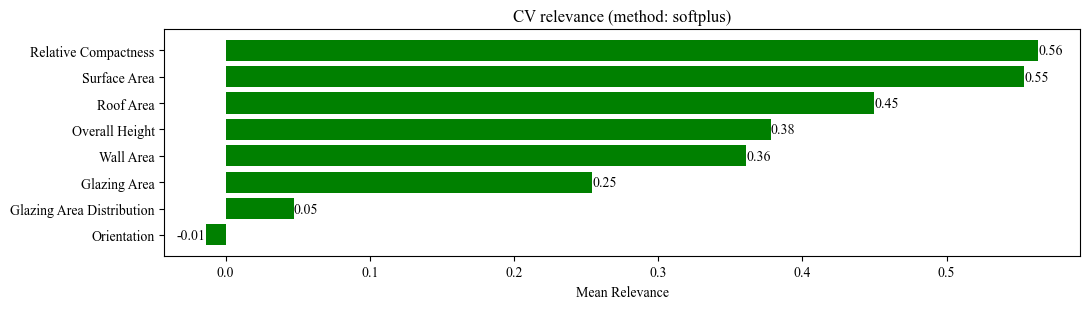

In [22]:
print_cv_relevance(softplus_results_higher_degs, X.columns)
plot_cv_relevance(softplus_results_higher_degs, X.columns)

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
param_softplus_results_higher_degs = cv_relevance(X, y,
                                                  N_feature=7, N_target=8,
                                                  method="softplus", a=3., b=100.)

CV Relevance Results (method: param-softplus):

Feature: Relative Compactness
  per fold: [0.65 0.71 0.75 0.75 0.81 0.79 0.59 0.71 0.64 0.88]
  mean relevance : 0.7272
  std relevance  : 0.0813

Feature: Surface Area
  per fold: [0.69 0.74 0.66 0.69 0.67 0.71 0.49 0.77 0.6  0.8 ]
  mean relevance : 0.6827
  std relevance  : 0.0833

Feature: Wall Area
  per fold: [0.41 0.47 0.15 0.44 0.48 0.06 0.02 0.28 0.23 0.24]
  mean relevance : 0.2779
  std relevance  : 0.1597

Feature: Roof Area
  per fold: [0.4  0.77 0.62 0.61 0.83 0.63 0.44 0.71 0.59 0.52]
  mean relevance : 0.6121
  std relevance  : 0.1290

Feature: Overall Height
  per fold: [0.48 0.67 0.6  0.61 0.69 0.55 0.45 0.62 0.62 0.49]
  mean relevance : 0.5785
  std relevance  : 0.0782

Feature: Orientation
  per fold: [-0.06 -0.08 -0.12 -0.15 -0.12 -0.12 -0.09 -0.03 -0.04 -0.09]
  mean relevance : -0.0891
  std relevance  : 0.0364

Feature: Glazing Area
  per fold: [ 0.08  0.2   0.15 -0.2   0.04  0.25  0.03  0.07 -0.12 -0.04]
  mean r

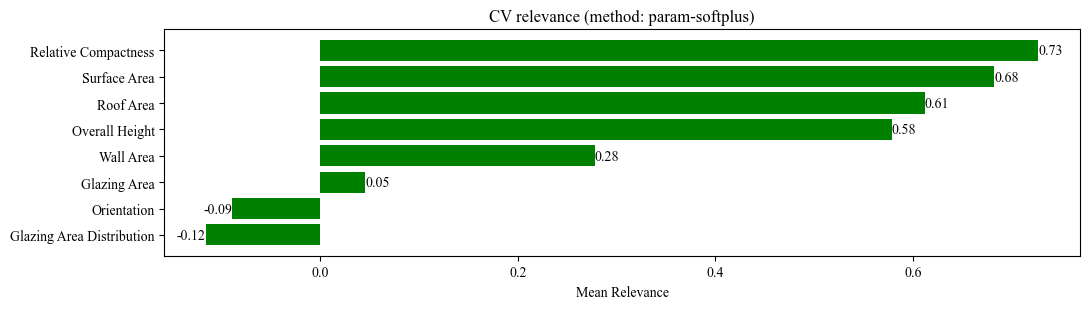

In [24]:
print_cv_relevance(param_softplus_results_higher_degs, X.columns, method="param-softplus")
plot_cv_relevance(param_softplus_results_higher_degs, X.columns, method="param-softplus")

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
clip_results_higher_degs = cv_relevance(X, y,
                                        N_feature=7, N_target=8,
                                        method="clip")

CV Relevance Results (method: clip):

Feature: Relative Compactness
  per fold: [0.75 0.76 0.76 0.79 0.8  0.77 0.42 0.75 0.41 0.82]
  mean relevance : 0.7019
  std relevance  : 0.1458

Feature: Surface Area
  per fold: [0.8  0.8  0.76 0.81 0.77 0.75 0.4  0.82 0.42 0.82]
  mean relevance : 0.7140
  std relevance  : 0.1559

Feature: Wall Area
  per fold: [0.58 0.57 0.44 0.6  0.43 0.42 0.41 0.51 0.5  0.33]
  mean relevance : 0.4784
  std relevance  : 0.0828

Feature: Roof Area
  per fold: [0.62 0.73 0.68 0.71 0.8  0.68 0.63 0.75 0.7  0.66]
  mean relevance : 0.6951
  std relevance  : 0.0514

Feature: Overall Height
  per fold: [0.58 0.64 0.62 0.63 0.65 0.61 0.57 0.63 0.63 0.58]
  mean relevance : 0.6157
  std relevance  : 0.0256

Feature: Orientation
  per fold: [-0.02 -0.02 -0.04 -0.04 -0.04 -0.04 -0.03 -0.01 -0.01 -0.03]
  mean relevance : -0.0269
  std relevance  : 0.0118

Feature: Glazing Area
  per fold: [ 0.36  0.38  0.34  0.24  0.36  0.3   0.35  0.32 -0.03  0.27]
  mean relevance :

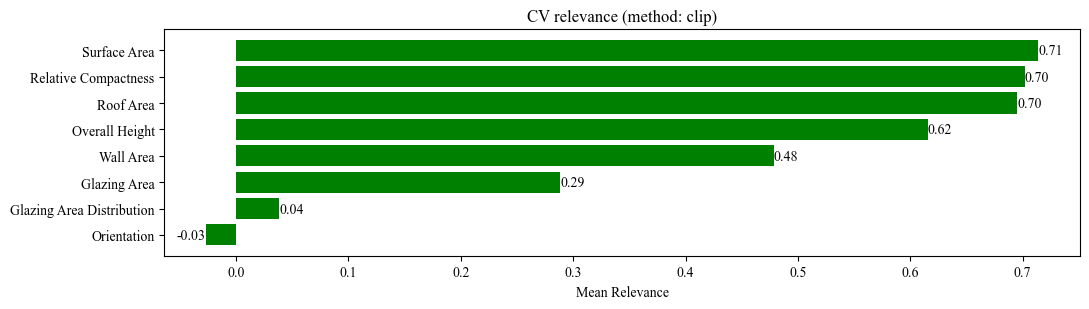

In [26]:
print_cv_relevance(clip_results_higher_degs, X.columns, method="clip")
plot_cv_relevance(clip_results_higher_degs, X.columns, method="clip")

In [27]:
from src.evaluation import relevance_to_df
relevance_df = relevance_to_df(softplus_results_higher_degs,
                               param_softplus_results_higher_degs,
                               clip_results_higher_degs)
relevance_df

softplus           param_softplus            \
                               mean       std           mean       std   
feature                                                                  
Relative Compactness       0.563708  0.018068       0.727165  0.081268   
Surface Area               0.553746  0.022723       0.682729  0.083336   
Wall Area                  0.361112  0.047057       0.277905  0.159737   
Roof Area                  0.449993  0.037800       0.612097  0.128967   
Overall Height             0.378251  0.018744       0.578490  0.078155   
Orientation               -0.013672  0.006205      -0.089129  0.036400   
Glazing Area               0.254364  0.041670       0.045679  0.131534   
Glazing Area Distribution  0.047199  0.034845      -0.115948  0.068653   

                               clip            
                               mean       std  
feature                                        
Relative Compactness       0.701931  0.145818  
Surface Area               0.713962  0.155941  
Wall Area                  0.478407  0.082815  
Roof Area                  0.695135  0.051389  
Overall Height             0.615691  0.025565  
Orientation               -0.026860  0.011843  
Glazing Area               0.288537  0.113563  
Glazing Area Distribution  0.038564  0.043755